# Minichallenge 2 Notebook 1
Dieses Notbook enthält die Abgaben für die Tage 1 - 4 für die GBSV Minichallenge 2. Der Code sowie die Daten sind in einem GitHub Repository verfügbar und unter diesem Link zu finden: [GitHub Repository](https://github.com/adrianmeier2002/gbsv_minichallenges).

## Tag 1: Augmentationsverfahren Definieren

Ich habe für die GBSV Minichallenge Kanada als Land gewählt, da Teile meiner Familie (Onkel und Cousin) in Kanada, genauer in Montreal, leben. Ich war selber schon zwei Mal in Kanada und habe gerade Montreal als sehr schöne Stadt in Erinnerung. Ich habe für die ersten Aufgeben drei verschiedene Bilder Gewählt. Das erste Bild ist eine eigene Aufnahme von mir, die ich in Montreal gemacht habe, darauf ist die Skyline von Montreal zu sehen, jedoch war zu dieser Zeit der [grosse Waldbrand](https://de.wikipedia.org/wiki/Waldbr%C3%A4nde_in_Kanada_2023) in Kanada (2023), weshalb der Himmel sehr Rauchig ist. Das Zweite Bild stammt von der Flagge Kanadas, dies ist ein sehr bekanntes Symbol für Kanada. Das Bild stammt vom [Wikipediaartikel](https://de.wikipedia.org/wiki/Flagge_Kanadas) zur Kanadischen Flagge. Als drittes Bild habe ich ein Bild mit viel Schnee gewählt, da Kanada für seine kalten Winter bekannt ist und dies für weitere analysen interessant sein könnte. Das Bild stammt aus der [kleine Kinderzeitung](https://kinderzeitung.kleinezeitung.at/nach-wintersturm-in-eis-und-schnee-gepackt/.)

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from skimage.metrics import structural_similarity as ssim, peak_signal_noise_ratio as psnr

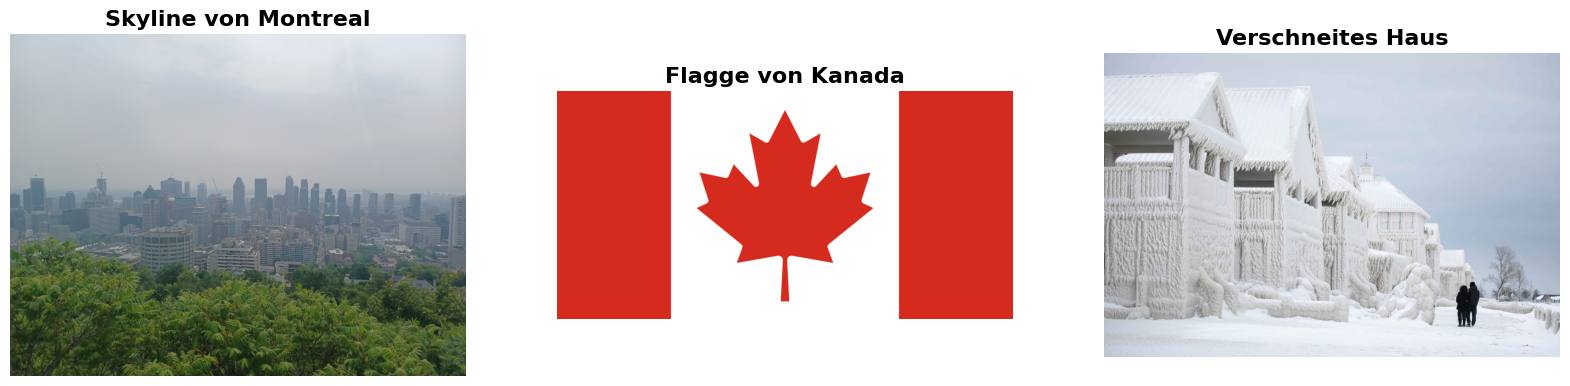

In [2]:
# Laden der Bilder
skyline = cv2.imread('Images/skyline.jpg')
flag = cv2.imread('Images/flag.jpg')
snow_house = cv2.imread('Images/snow_house.jpg')

# Ausgeben der Bilder
images = [skyline, flag, snow_house]
titles = ['Skyline von Montreal', 'Flagge von Kanada', 'Verschneites Haus']
plt.figure(figsize=(20,10))
for i in range(3):
    plt.subplot(1, 3, i+1)
    plt.imshow(cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB))
    plt.title(titles[i], fontsize=16, fontweight='bold')
    plt.axis('off')
plt.show()



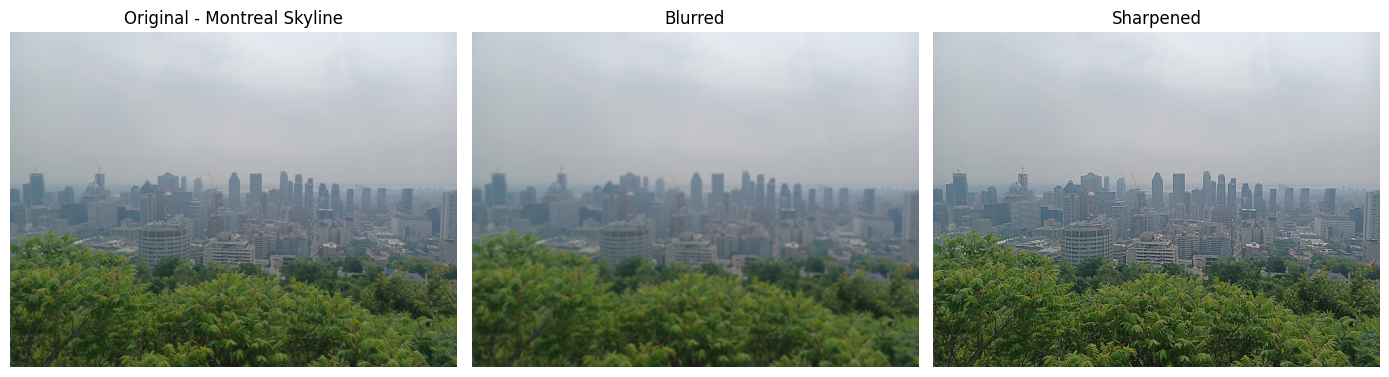

In [3]:
# Hilfsfunktion für Darstellung
def show(imgs, titles, cmap='gray'):
    plt.figure(figsize=(14,4))
    for i, (im, t) in enumerate(zip(imgs, titles)):
        plt.subplot(1, len(imgs), i+1)
        if len(im.shape) == 2:
            plt.imshow(im, cmap=cmap)
        else:
            plt.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
        plt.title(t)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Gaussian Blur auf das Skyline Bild anwenden
blurred = cv2.GaussianBlur(skyline, (9, 9), 10)

sharpened = cv2.addWeighted(skyline, 2, blurred, -1, 0)

show([skyline, blurred, sharpened], ['Original - Montreal Skyline', 'Blurred', 'Sharpened'])

Hier wurde das Augmentationsverfahren zur Schärfung des Skyline Bildes angewendet.

Für die Schärfung des Skyline Bildes habe ich zuerst ein Gaussian Blur angewendet, dieser ersetzt jedes Pixel durch den gewichteten Durchschnitt seiner Nachbarpixel, wodurch das Bild unschärfer wird. Anschliessend habe ich das ursprüngliche Bild mit dem unscharfen Bild kombiniert, indem ich das unscharfe Bild mit einem negativen Gewicht multipliziert und zum ursprünglichen Bild addiert habe. Dies hebt die Kanten im Bild hervor und erzeugt einen Schärfungseffekt. Die Parameter habe ich experimentell gewählt, wenn das Verhältnis nicht stimmt, sieht das Bild schnell unnatürlich oder zu dunkel aus.

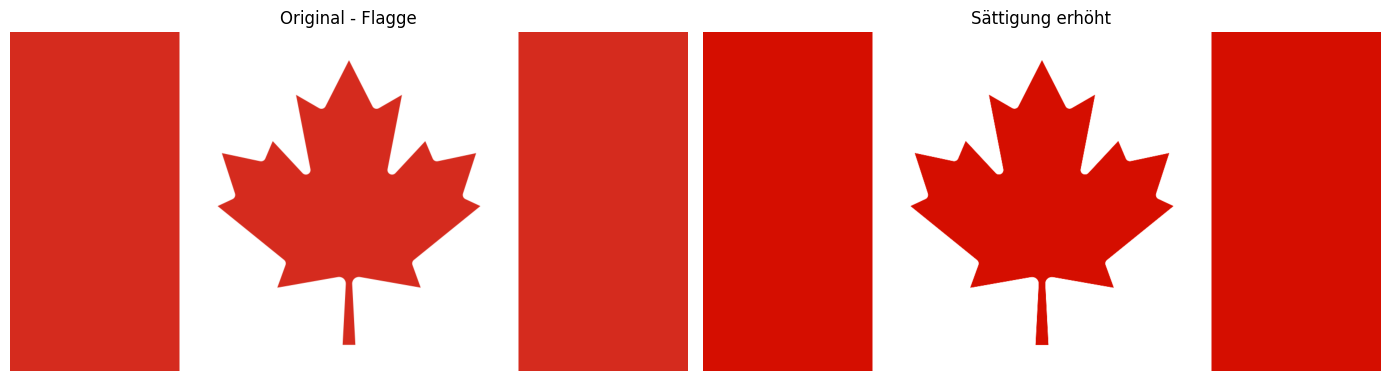

In [4]:
hsv = cv2.cvtColor(flag, cv2.COLOR_BGR2HSV).astype("float32")
hsv[...,1] *= 2 # Sättigung erhöhen
hsv[...,1] = np.clip(hsv[...,1], 0, 255)
img_flag_boost = cv2.cvtColor(hsv.astype("uint8"), cv2.COLOR_HSV2BGR)

show([flag, img_flag_boost], ['Original - Flagge', 'Sättigung erhöht'])

Hier wurde das Augmentationsverfahren zur Erhöhung der Sättigung des Flaggen Bildes angewendet.

Dabei wurde das Bild zuerst von RGB in den HSV Farbraum konvertiert. Anschliessend wurde der Sättigungswert (S) jedes Pixels um den Faktor 2 erhöht, wobei darauf geachtet wurde, dass der Wert 255 nicht überschritten wird. Danach wurde das Bild zurück in den RGB Farbraum konvertiert, um das Ergebnis zu erhalten. Dies führt zu lebendigeren Farben im Bild.

<span style="background-color:yellow">
Um die Veränderung der Sättigung besser quantifizieren zu können, habe ich zusätzlich die Histogramme des S-Kanals (Sättigung) vor und nach der Augmentation dargestellt. Dies zeigt klar, wie stark die Verteilung der Sättigungswerte verschoben wird und macht den Effekt objektiver nachvollziehbar.
</span>

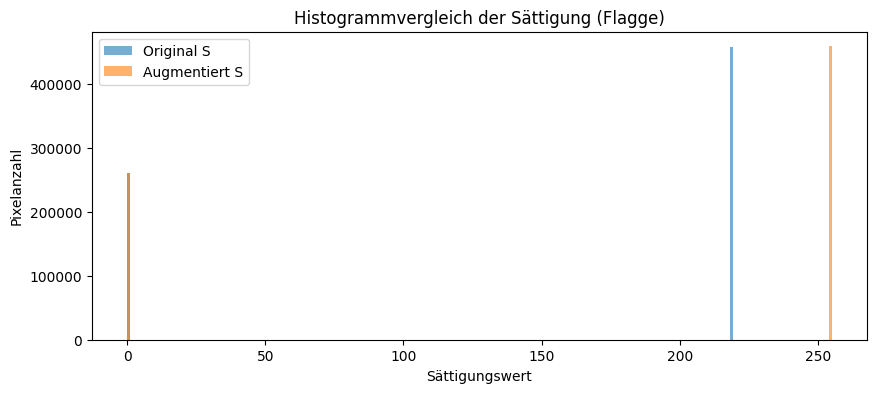

In [10]:
# Histogrammvergleich der Sättigung der Flagge
hsv_orig = cv2.cvtColor(flag, cv2.COLOR_RGB2HSV)
hsv_aug = cv2.cvtColor(img_flag_boost, cv2.COLOR_RGB2HSV)

plt.figure(figsize=(10,4))
plt.hist(hsv_orig[...,1].ravel(), bins=256, alpha=0.6, label="Original S", range=(0,255))
plt.hist(hsv_aug[...,1].ravel(), bins=256, alpha=0.6, label="Augmentiert S", range=(0,255))
plt.legend()
plt.title("Histogrammvergleich der Sättigung (Flagge)")
plt.xlabel("Sättigungswert")
plt.ylabel("Pixelanzahl")
plt.show()


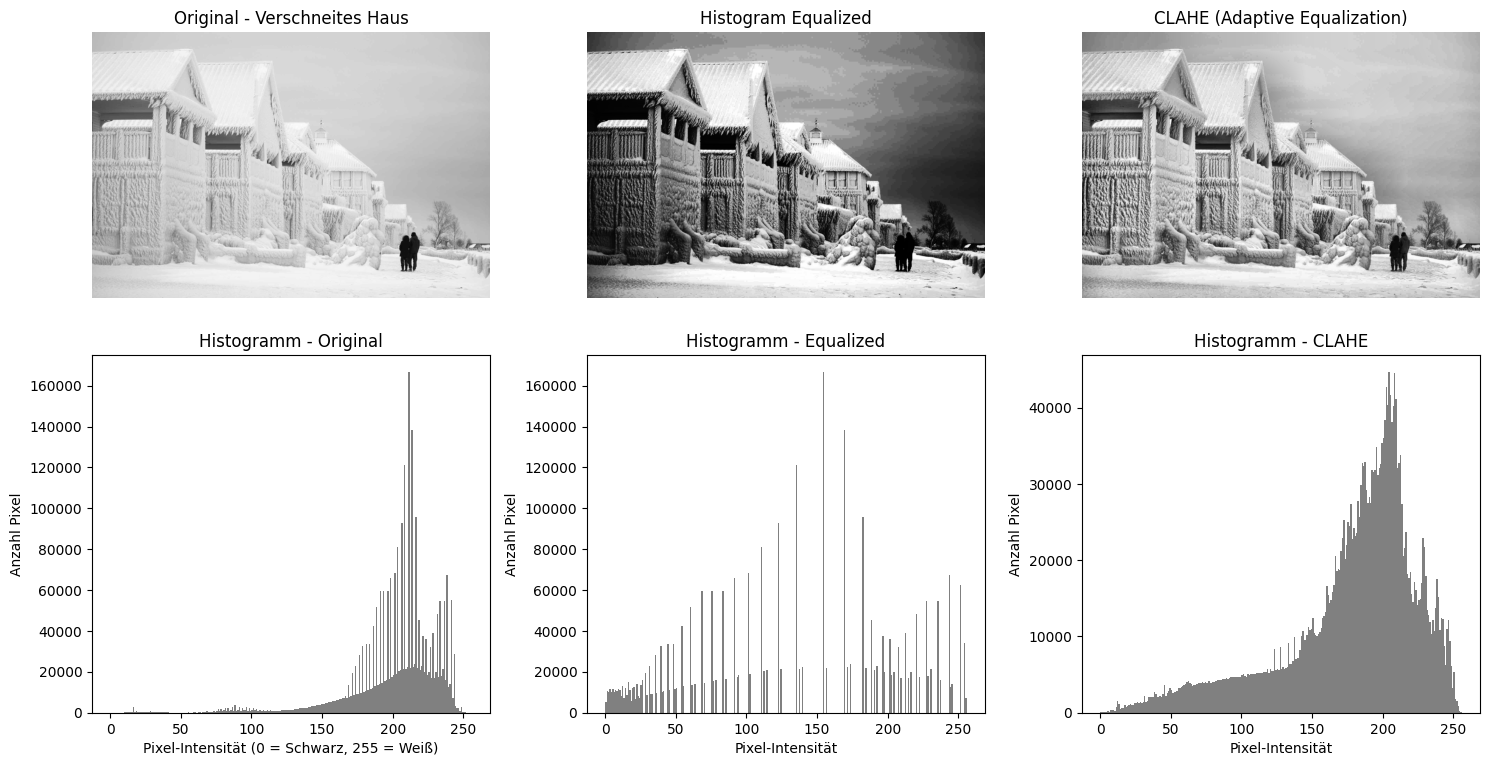

In [5]:
# --- Lade Graustufenbild ---
snow_house_grey = cv2.imread('Images/snow_house.jpg', cv2.IMREAD_GRAYSCALE)
if snow_house_grey is None:
    raise FileNotFoundError("Fehler: 'Images/snow_house.jpg' nicht gefunden!")

# --- Normale Histogramm Equalization ---
house_equalized = cv2.equalizeHist(snow_house_grey)

# --- CLAHE (lokale Anpassung) ---
clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
house_clahe = clahe.apply(snow_house_grey)

# --- Darstellung der Bilder & Histogramme ---
fig, axs = plt.subplots(2, 3, figsize=(15, 8))

# --- Originalbild ---
axs[0,0].imshow(snow_house_grey, cmap='gray')
axs[0,0].set_title('Original - Verschneites Haus')
axs[0,0].axis('off')

axs[1,0].hist(snow_house_grey.ravel(), bins=256, range=(0, 256), color='gray')
axs[1,0].set_title('Histogramm - Original')
axs[1,0].set_xlabel('Pixel-Intensität (0 = Schwarz, 255 = Weiß)')
axs[1,0].set_ylabel('Anzahl Pixel')

# --- Histogramm Equalization ---
axs[0,1].imshow(house_equalized, cmap='gray')
axs[0,1].set_title('Histogram Equalized')
axs[0,1].axis('off')

axs[1,1].hist(house_equalized.ravel(), bins=256, range=(0, 256), color='gray')
axs[1,1].set_title('Histogramm - Equalized')
axs[1,1].set_xlabel('Pixel-Intensität')
axs[1,1].set_ylabel('Anzahl Pixel')

# --- CLAHE ---
axs[0,2].imshow(house_clahe, cmap='gray')
axs[0,2].set_title('CLAHE (Adaptive Equalization)')
axs[0,2].axis('off')

axs[1,2].hist(house_clahe.ravel(), bins=256, range=(0, 256), color='gray')
axs[1,2].set_title('Histogramm - CLAHE')
axs[1,2].set_xlabel('Pixel-Intensität')
axs[1,2].set_ylabel('Anzahl Pixel')

plt.tight_layout()
plt.show()


Hier wurde das Augmentationsverfahren zur Kontrastverbesserung des verschneiten Haus Bildes angewendet.

Die Schneebedekten Häuser wirken oft sehr grau und kontrastarm. Um den Kontrast zu verbessern, habe ich die CLAHE (Contrast Limited Adaptive Histogram Equalization) Methode verwendet. Diese Methode verbessert den Kontrast in lokalen Bereichen des Bildes, indem sie die Helligkeitswerte anpasst, ohne dabei zu viel Rauschen zu erzeugen. Dies führt zu einem klareren und kontrastreicheren Bild des verschneiten Hauses. Dies ist in diesem Fall besonders nützlich, da bei einer globalen Histogrammgleichung oft zu viel Rauschen in den hellen Bereichen des Schnees entsteht. Dadurch scheint das Bild zu überkontrastiert.

## Tag 2: Use Case

### Skyline Bild - Schärfung
Die Schärfung eines Bildes kann in verschiedenen Anwendungsfällen nützlich sein, insbesondere wenn das Bild unscharf oder verschwommen ist. Im Usecase der Skyline von Montreal habe ich das Problem, dass meine Aufnahme durch den Rauch der Waldbrände unscharf und verschwommen wirkt ohne dass ich oder eine andere Kameraeinstellung dies beeinflussen konnte. Durch die Schärfung des Bildes kann ich die Details der Skyline besser hervorheben und das Bild klarer und ansprechender machen. Dies ist besonders wichtig, wenn das Bild für Präsentationen, Veröffentlichungen oder persönliche Erinnerungen verwendet wird.

<span style="background-color:yellow">
Um die Schärfung des Bildes zu quantifizieren, soll der Laplacian-Varianzwert des Bildes vor und nach der Schärfung berechnet werden. Dabei soll der Wert deutlich erhöht werden (auf mindestens das Doppelte) und der SSIM-Wert also die Ähnlichkeit zwischen dem Originalbild und dem geschärften Bild soll hoch bleiben (über0.75).
</span>

### Flaggen Bild - Sättigung erhöhen
Die Erhöhung der Sättigung eines Bildes kann dazu beitragen, die Farben lebendiger und ansprechender zu gestalten. Im Usecase der Kanadischen Flagge kann eine erhöhte Sättigung dazu beitragen, die Rot- und Weißtöne der Flagge hervorzuheben, wodurch das Bild auffälliger und attraktiver wird. Gerade das Rot der Kanadischen Flagge ist im Original etwas blass, durch die Erhöhung der Sättigung wirkt das Rot kräftiger und symbolisiert die Flagge besser. Dies ist besonders wichtig, wenn das Bild für Werbezwecke verwendet wird und mit dem Rot der Flagge Aufmerksamkeit erregen soll.


### Verschneites Haus Bild - Kontrastverbesserung
Die Kontrastverbesserung eines Bildes kann dazu beitragen, die Details und Strukturen im Bild besser sichtbar zu machen. Im Usecase des verschneiten Hauses kann eine verbesserte Kontrastdarstellung dazu beitragen, die verschiedenen Elemente des Bildes, also die einzelnen Häuser, den Schnee und den Himmel, besser voneinander zu unterscheiden. Ohne die Kontrastverbesserung wirken die Häuser oft grau und es ist teilweise nur schwer zu erkennen, wo die Häuser aufhören und der Schnee beginnt oder ob die Häuser aneinanderhängen oder nicht. Durch eine verbesserte Kontrastdarstellung mithilfe von Histogrammequalisierung können die Unterschiede zwischen den verschiedenen Elementen im Bild hervorgehoben werden, was zu einem klareren Bild führt. Um das Bild etwas natürlicher zu halten, habe ich zudem noch CLAHE verwendet, da bei einer normalen Histogrammgleichung oft zu viel Rauschen in den hellen Bereichen des Schnees entsteht. Mit CLAHE wird der Kontrast lokal angepasst, was zu einem natürlicheren Ergebnis führt.

## Tag 3: Anwendung der Augmentationsverfahren

In [6]:
# Lade Bild (RGB für Anzeige/SSIM)
sky_bgr = cv2.imread('Images/skyline.jpg')
if sky_bgr is None:
    raise FileNotFoundError("Images/skyline.jpg nicht gefunden")
sky = cv2.cvtColor(sky_bgr, cv2.COLOR_BGR2RGB)

alphas = np.linspace(0.2, 2.5, 10)      # Schärfe-Faktoren
sigmas = [1, 2, 4, 6, 8]                # Gaussian blur sigma
results = []

for alpha in alphas:
    for sigma in sigmas:
        # Wähle Kernel aus (odd) abhängig von sigma
        k = int(max(3, 2*int(3*sigma)+1))
        blurred = cv2.GaussianBlur(sky, (k,k), sigmaX=sigma, sigmaY=sigma)
        sharpened = cv2.addWeighted(sky, 1+alpha, blurred, -alpha, 0)

        # Metriken
        ssim_val = ssim(sky, sharpened, channel_axis=-1)
        psnr_val = psnr(sky, sharpened, data_range=255)
        lap_var = cv2.Laplacian(cv2.cvtColor(sharpened, cv2.COLOR_RGB2GRAY), cv2.CV_64F).var()
        results.append({'alpha': alpha, 'sigma': sigma, 'ssim': ssim_val, 'psnr': psnr_val, 'lap_var': lap_var, 'img': sharpened})

# Beispiel: Top-3 nach Laplacian (schärfste Varianten)
sorted_by_sharp = sorted(results, key=lambda x: -x['lap_var'])
print("Top drei schärfste Varianten:")
for r in sorted_by_sharp[:3]:
    print(f"alpha={r['alpha']}, sigma={r['sigma']}, lap_var={r['lap_var']:.1f}, ssim={r['ssim']:.3f}, psnr={r['psnr']:.2f}")

Top drei schärfste Varianten:
alpha=2.5, sigma=4, lap_var=2639.7, ssim=0.774, psnr=21.51
alpha=2.5, sigma=6, lap_var=2619.9, ssim=0.760, psnr=20.71
alpha=2.5, sigma=2, lap_var=2619.7, ssim=0.812, psnr=23.53


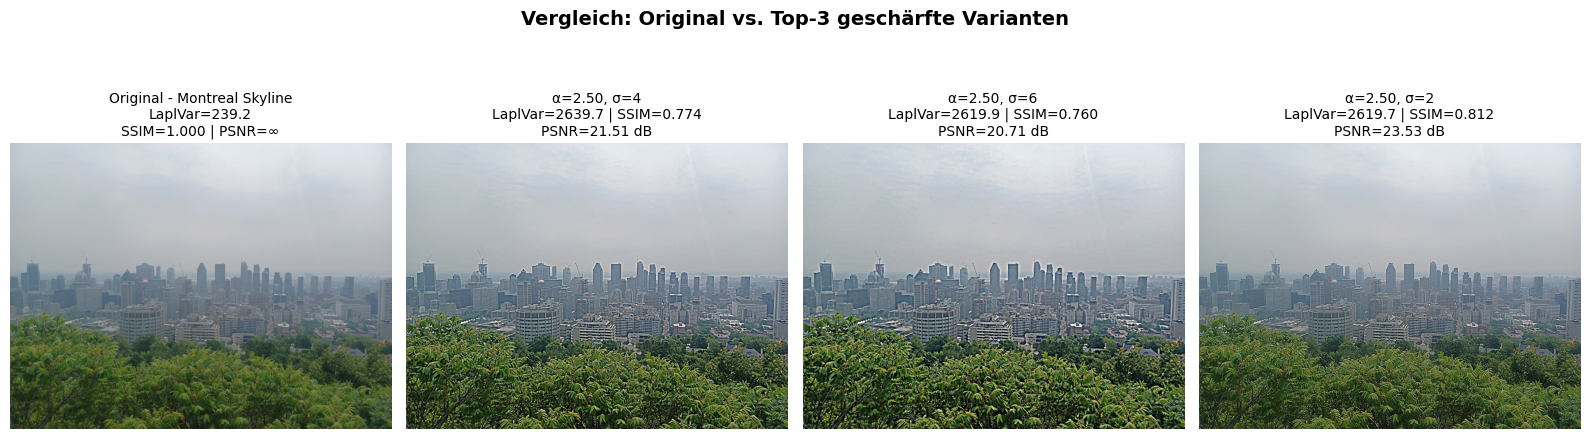

In [7]:
# --- Plot: Original + Top-3 schärfste Varianten ---
top3 = sorted_by_sharp[:3]
imgs = [sky] + [r['img'] for r in top3]
titles = ['Original - Montreal Skyline'] + [f"α={r['alpha']:.2f}, σ={r['sigma']}" for r in top3]

plt.figure(figsize=(16,5))
for i, (img, title) in enumerate(zip(imgs, titles)):
    plt.subplot(1, len(imgs), i+1)
    
    # Sicherstellen, dass Farben korrekt angezeigt werden (RGB)
    plt.imshow(img)
    plt.axis('off')
    
    # Kennzahlen unter dem Titel
    if i == 0:
        plt.title(f"{title}\nLaplVar={cv2.Laplacian(cv2.cvtColor(img, cv2.COLOR_RGB2GRAY), cv2.CV_64F).var():.1f}\nSSIM=1.000 | PSNR=∞", fontsize=10)
    else:
        r = top3[i-1]
        plt.title(
            f"{title}\nLaplVar={r['lap_var']:.1f} | SSIM={r['ssim']:.3f}\nPSNR={r['psnr']:.2f} dB",
            fontsize=10
        )

plt.suptitle("Vergleich: Original vs. Top-3 geschärfte Varianten", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

$\alpha$ ist der Verstärkungsfaktor für die Schärfung des Bildes.  
$\sigma$ ist die Standardabweichung des Gausschen Weichzeichners, der verwendet wird, um das Bild unscharf zu machen.   
Je höher der Wert von $\alpha$, desto stärker wird das Bild geschärft. Ein höher $\sigma$-Wert führt zu einem stärkeren Weichzeichner, was bedeutet, dass das Bild unschärfer wird, bevor die Schärfung angewendet wird.

**SSMI**:  
Mithilfe des SSIM (Structural Similarity Index Measure) wird die Ähnlichkeit zwischen dem Originalbild und dem augmentierten Bild gemessen. SSIM bewertet die Bildqualität basierend auf drei Hauptkomponenten: Luminanz, Kontrast und Struktur. Der SSIM-Wert liegt zwischen -1 und 1, wobei 1 bedeutet, dass die beiden Bilder identisch sind. Ein höherer SSIM-Wert deutet darauf hin, dass das augmentierte Bild dem Originalbild ähnlicher ist, während ein niedrigerer Wert auf grössere Unterschiede hinweist.

**PSNR**:
Der PSNR (Peak Signal-to-Noise Ratio) ist ein Mass für die Qualität eines rekonstruierten Bildes im Vergleich zu einem Originalbild. Er wird in Dezibel (dB) gemessen und gibt das Verhältnis zwischen dem maximal möglichen Signalwert und dem Rauschpegel an, der durch die Augmentation eingeführt wurde. Ein höherer PSNR-Wert deutet auf eine bessere Qualität des augmentierten Bildes hin, da er darauf hinweist, dass das Rauschen im Vergleich zum Signal gering ist.

**Laplacian Varianz**:
Die Laplacian Varianz ist ein Mass für die Schärfe eines Bildes. Sie wird berechnet, indem der Laplace-Operator auf das Bild angewendet wird, um die Kanten und Details hervorzuheben, und dann die Varianz der resultierenden Werte gemessen wird. Eine höhere Laplacian Varianz deutet darauf hin, dass das Bild schärfer ist, da es mehr Kanten und Details enthält.

Man sieht durch die Optimierungen klar, dass die Gebäude und der Wald im Vordergrund deutlicher werden und die Konturen der Gebäude besser hervorgehoben werden.

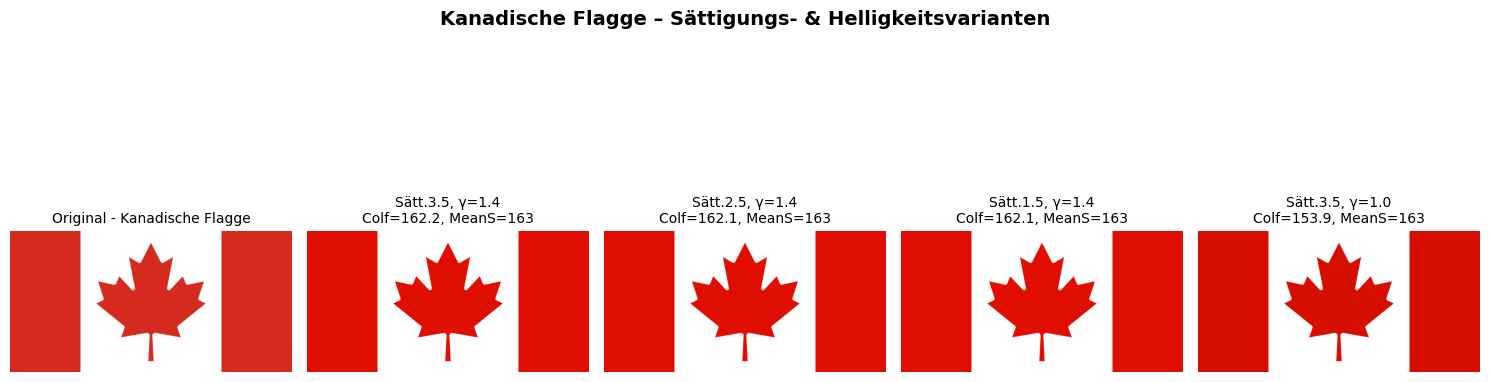

In [8]:
# Hilfsfunktion: Colorfulness (Hasler & Süsstrunk-like)
def colorfulness(img_rgb):
    R, G, B = img_rgb[:,:,0].astype(float), img_rgb[:,:,1].astype(float), img_rgb[:,:,2].astype(float)
    rg = R - G
    yb = 0.5*(R + G) - B
    std_rg, std_yb = np.std(rg), np.std(yb)
    mean_rg, mean_yb = np.mean(rg), np.mean(yb)
    return np.sqrt(std_rg**2 + std_yb**2) + 0.3*np.sqrt(mean_rg**2 + mean_yb**2)

# Lade Flagge (RGB)
flag_bgr = cv2.imread('Images/flag.jpg')
if flag_bgr is None:
    raise FileNotFoundError("Images/flag.jpg nicht gefunden")
flag = cv2.cvtColor(flag_bgr, cv2.COLOR_BGR2RGB)

# Hier: stärkere Parameter, um Unterschiede deutlicher zu machen
factors = [0.8, 1.0, 1.5, 2.5, 3.5]   # Skalierung der Sättigung
gammas = [0.7, 1.0, 1.4]              # Helligkeitsanpassung über Value-Kanal

stats = []

for f in factors:
    for g in gammas:
        hsv = cv2.cvtColor(flag, cv2.COLOR_RGB2HSV).astype(np.float32)
        # Sättigung erhöhen/abschwächen
        hsv[...,1] = np.clip(hsv[...,1] * f, 0, 255)
        # Helligkeit (Gamma)
        V = hsv[...,2] / 255.0
        V = np.clip(V ** (1.0/g), 0, 1)
        hsv[...,2] = (V * 255.0)
        out = cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2RGB)

        # Metriken
        mean_sat = np.mean(hsv[...,1])
        mean_red = np.mean(out[:,:,0])
        colf = colorfulness(out)
        stats.append({'factor': f, 'gamma': g, 'mean_sat': mean_sat, 'mean_red': mean_red,
                      'colorfulness': colf, 'img': out})

# Sortiere nach Colorfulness
top = sorted(stats, key=lambda x: -x['colorfulness'])[:4]  # 4 Varianten

# === Plot mit Original + Top-4 ===
plt.figure(figsize=(15,5))
all_imgs = [flag] + [r['img'] for r in top]
titles = ["Original - Kanadische Flagge"] + [
    f"Sätt.{r['factor']:.1f}, γ={r['gamma']}\nColf={r['colorfulness']:.1f}, MeanS={r['mean_sat']:.0f}"
    for r in top
]

for i, (img, title) in enumerate(zip(all_imgs, titles)):
    plt.subplot(1, len(all_imgs), i+1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(title, fontsize=10)

plt.suptitle("Kanadische Flagge – Sättigungs- & Helligkeitsvarianten", fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()


**Sättigung (faktor)**:  
Mit dem Sättigungsfaktor wird die Intensität der Farben im Bild gesteuert.

**Gamma**:  
$\gamma$ ist der Kontrastverstärkungsfaktor für die Kontrastverbesserung des Bildes.

**Colf**:  
Die Colorfulness (Colf) ist ein Mass für die Farbsättigung und Lebendigkeit eines Bildes. Sie wird berechnet, indem die Unterschiede zwischen den Farbkanälen (Rot, Grün und Blau) analysiert werden. Ein höherer Colf-Wert deutet darauf hin, dass das Bild lebendigere und gesättigtere Farben aufweist, während ein niedrigerer Wert auf ein blasseres oder graueres Bild hinweist.

**MeanS**:  
Die Mean Saturation (MeanS) ist der durchschnittliche Sättigungswert aller Pixel in einem Bild. Sie wird berechnet, indem die Sättigungswerte jedes Pixels summiert und durch die Gesamtzahl der Pixel im Bild geteilt werden. Ein höherer MeanS-Wert deutet darauf hin, dass das Bild insgesamt gesättigtere Farben aufweist, während ein niedrigerer Wert auf ein blasseres oder graueres Bild hinweist.

In den Bildern wird klar, das die Farben der Flagge kräftiger und lebendiger wirken als im Originalbild. Bei den Optimierten Bildern gibt es auch einen Unterschied in den Sättigungen und beim letzten Bild in der Helligkeit (kleineres Gamma).

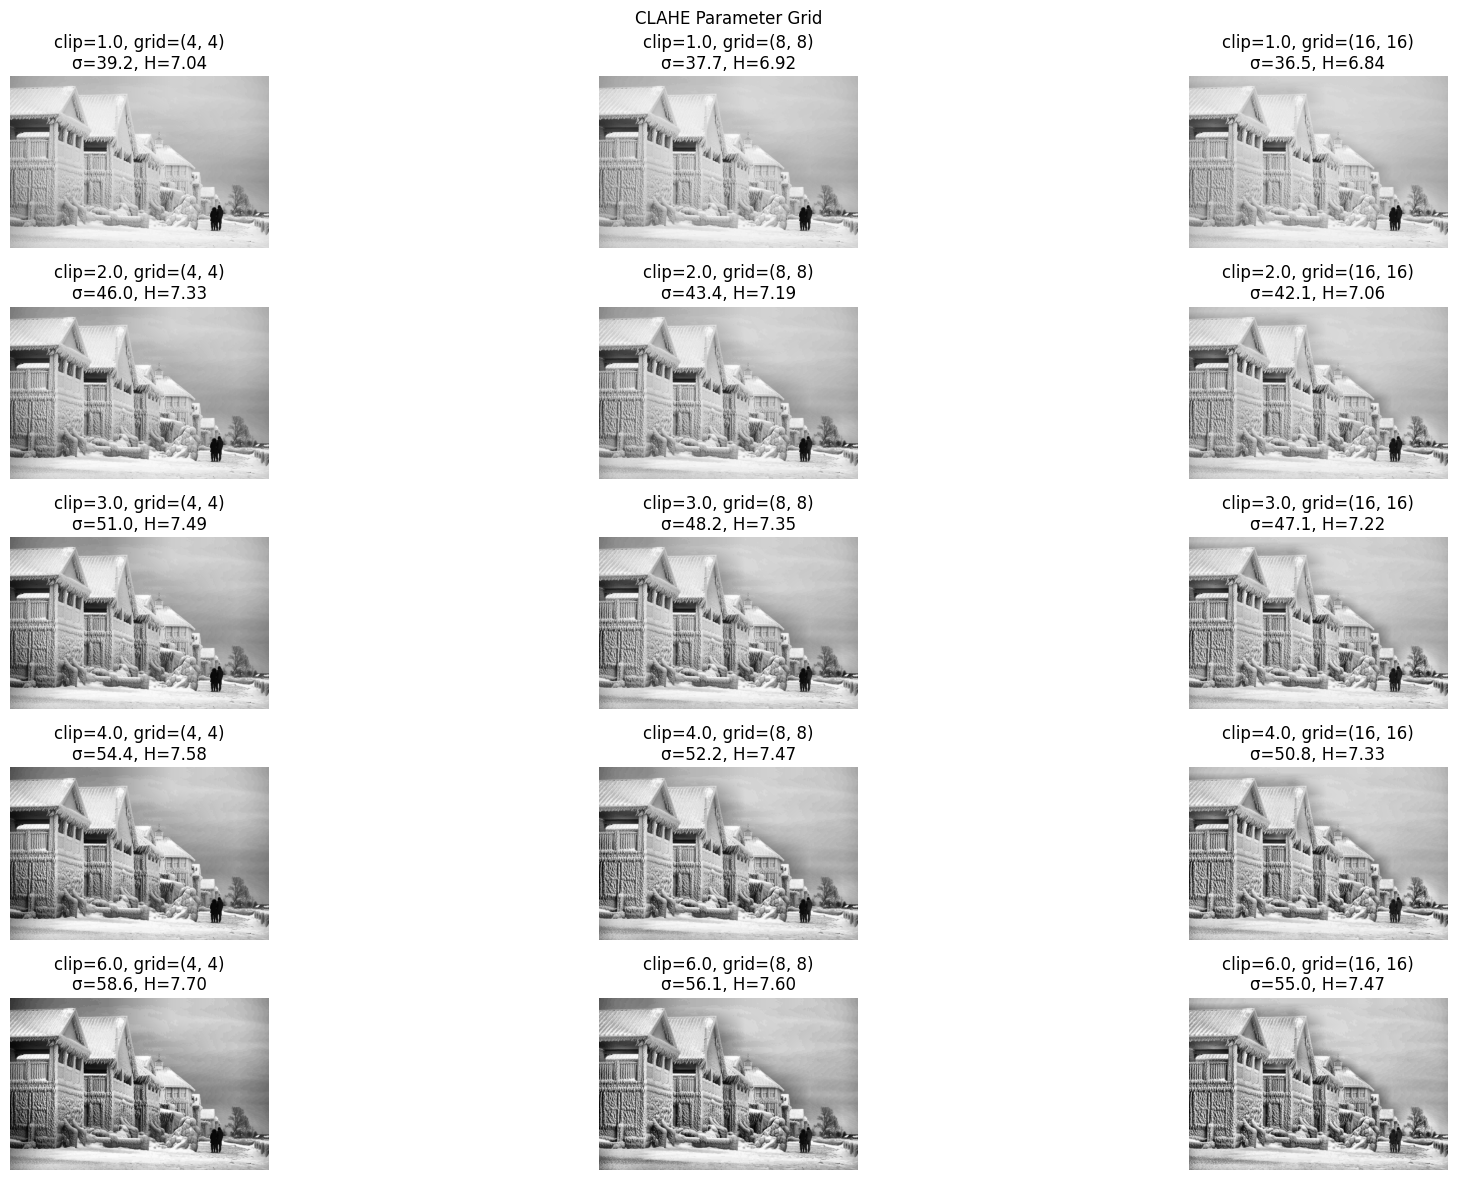

In [9]:
img_gray = cv2.imread('Images/snow_house.jpg', cv2.IMREAD_GRAYSCALE)
if img_gray is None:
    raise FileNotFoundError("Images/snow_house.jpg nicht gefunden")

clip_limits = [1.0, 2.0, 3.0, 4.0, 6.0]
grid_sizes = [(4,4), (8,8), (16,16)]
results = []
for c in clip_limits:
    for gs in grid_sizes:
        clahe = cv2.createCLAHE(clipLimit=c, tileGridSize=gs)
        out = clahe.apply(img_gray)
        std = np.std(out)
        ent = -np.sum((np.bincount(out.ravel(), minlength=256)/out.size) * np.log2((np.bincount(out.ravel(), minlength=256)/out.size) + 1e-12))
        results.append({'clip':c, 'grid':gs, 'std':std, 'entropy':ent, 'img':out})

# Visualisiere als Grid (rows=clipLimits, cols=gridSizes)
plt.figure(figsize=(20,12))
for i,c in enumerate(clip_limits):
    for j,gs in enumerate(grid_sizes):
        r = next(x for x in results if x['clip']==c and x['grid']==gs)
        plt_idx = i*len(grid_sizes) + j + 1
        plt.subplot(len(clip_limits), len(grid_sizes), plt_idx)
        plt.imshow(r['img'], cmap='gray'); plt.axis('off')
        plt.title(f"clip={c}, grid={gs}\nσ={r['std']:.1f}, H={r['entropy']:.2f}")
plt.suptitle("CLAHE Parameter Grid")
plt.tight_layout(); plt.show()

Wie Bereits am Vorherigen Tag erwähnt, nehme ich an, dass die CLAHE Methode für die Kontrastverbesserung des verschneiten Hauses besser geeignet ist, da sie den Kontrast lokal anpasst und somit ein natürlicheres Ergebnis erzielt. Bei einer normalen Histogrammgleichung entsteht oft zu viel Rauschen in den hellen Bereichen des Schnees, was das Bild unnatürlich wirken lässt. Ich teste hier verschiedene Werte für CLAHE.

**clip**:  
CLAHE verwendet einen Clip-Limit-Parameter, der bestimmt, wie stark die Histogrammgleichung begrenzt wird. Ein höheres Clip-Limit ermöglicht eine stärkere Kontrastverstärkung, während ein niedrigeres Clip-Limit den Kontrast subtiler hält.

**grid**:
Der Grid-Size-Parameter von CLAHE bestimmt die Grösse der lokalen Bereiche, in denen die Histogrammgleichung angewendet wird. Ein kleineres Grid führt zu einer feineren Anpassung des Kontrasts, während ein grösseres Grid zu einer gröberen Anpassung führt.

**Standardabweichung**:
Die Standardabweichung $\sigma$ misst die Streuung der Pixelwerte im Bild. Eine höhere Standardabweichung deutet auf ein kontrastreicheres Bild hin, während eine niedrigere Standardabweichung auf ein kontrastarmes Bild hinweist.

**Entropy**:
Die Entropie (H) ist ein Mass für die Informationsdichte eines Bildes. Sie wird berechnet, indem die Häufigkeit der verschiedenen Pixelwerte im Bild analysiert wird. Eine höhere Entropie deutet darauf hin, dass das Bild mehr Details und Variationen aufweist, während eine niedrigere Entropie auf ein einfacheres oder homogeneres Bild hinweist.

Aus den Bildern wird klar, dass die Häuser und der Schnee deutlicher voneinander getrennt sind und die Details der Häuser besser sichtbar werden. Gerade bei hohen Clip-Limits und kleinen Grid-Sizes sind die Details der Häuser am besten zu erkennen. Jedoch wirken diese Bilder auch etwas unnatürlich, weshalb ich persönlich die mittleren Werte bevorzuge.

## Tag 4: Disskussion der Methoden und Ergebnisse
Es wird bei allen drei Augmentationsverfahren klar, dass mit einigen Optimierungen die Bildqualität in eine gezielte Richtung verbessert werden kann. Es kann dabei sinnvoll sein Metriken zu verwenden um die Qualität der Augmentationen zu bewerten und zu vergleichen. Jedoch ist es wichtig zu beachten, dass diese Metriken zwar oftmals den Effekt der Augmentation optimieren aber das Bild selbst am Ende nicht immer besser wirken lassen. Ich habe deshalb das gefühl, dass man sich erstens bewusst sein muss, was man optimieren will und zweitens neben den Metriken auch den visuellen Eindruck des Bildes berücksichtigen muss. Dies ist natürlich vom Anwendungsfall abhängig, wenn es Beispielsweise enorm wichtig ist, Kanten zu erkennen, dann spielt der visuelle Eindruck eine untergeordnete Rolle. Es ist beeindrucken mit welchen teils Simplen Methoden Bilder geändert werden können und welche Details aus verschwommenen Bildern wie Beispielsweise der Skyline dennoch gewonnen werden können.